<a href="https://colab.research.google.com/github/ChayatornOunpat/2190512-Application-Development/blob/master/Week03_exercise_Covid19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Covid19 Data Visualization with Pandas
Using Covid19 data from Center for Systems Science and Engineering (CSSE) at Johns Hopkins University.

See: https://github.com/CSSEGISandData/COVID-19/tree/master/csse_covid_19_data/csse_covid_19_time_series

*   Read `time_series_covid19_confirmed_global.csv` from https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv into a DataFrame
*   Explore top n rows: **`DataFrame.head(n=5)`** returns the first `n` rows for the object based on position.

In [61]:
import pandas as pd
import seaborn

df=pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv')

The DataFrame contains number of confirmed cases by `Province/State`, `Country/Region`, `Lat`, `Long` and dates.

In [40]:
df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


Observe data series from column `Country/Region` in the data frame.

In [41]:
df['Country/Region']

0               Afghanistan
1                   Albania
2                   Algeria
3                   Andorra
4                    Angola
               ...         
284      West Bank and Gaza
285    Winter Olympics 2022
286                   Yemen
287                  Zambia
288                Zimbabwe
Name: Country/Region, Length: 289, dtype: str

Try slice for only data that `Country/Region` is 'China'.

In [42]:
cdf = df[df['Country/Region'] == "China"]
cdf

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
59,Anhui,China,31.8257,117.2264,1,9,15,39,60,70,...,2275,2275,2275,2275,2275,2275,2275,2275,2275,2275
60,Beijing,China,40.1824,116.4142,14,22,36,41,68,80,...,40774,40774,40774,40774,40774,40774,40774,40774,40774,40774
61,Chongqing,China,30.0572,107.8740,6,9,27,57,75,110,...,14715,14715,14715,14715,14715,14715,14715,14715,14715,14715
62,Fujian,China,26.0789,117.9874,1,5,10,18,35,59,...,17122,17122,17122,17122,17122,17122,17122,17122,17122,17122
63,Gansu,China,35.7518,104.2861,0,2,2,4,7,14,...,1742,1742,1742,1742,1742,1742,1742,1742,1742,1742
64,Guangdong,China,23.3417,113.4244,26,32,53,78,111,151,...,103248,103248,103248,103248,103248,103248,103248,103248,103248,103248
65,Guangxi,China,23.8298,108.7881,2,5,23,23,36,46,...,13371,13371,13371,13371,13371,13371,13371,13371,13371,13371
66,Guizhou,China,26.8154,106.8748,1,3,3,4,5,7,...,2534,2534,2534,2534,2534,2534,2534,2534,2534,2534
67,Hainan,China,19.1959,109.7453,4,5,8,19,22,33,...,10483,10483,10483,10483,10483,10483,10483,10483,10483,10483
68,Hebei,China,39.5490,116.1306,1,1,2,8,13,18,...,3292,3292,3292,3292,3292,3292,3292,3292,3292,3292


`pandas.DataFrame.groupby()` creates `DataFrameGroupBy` object using the speficied aggregation function.
*   Create a new DataFrame that `sum` confirmed cases for each `Country/Region`



In [62]:
ldf = df[["Province/State","Lat", "Long"]]
ddf = df.drop("Lat", axis=1)
ddf.drop("Long", axis=1, inplace=True)
ddf.drop("Province/State", axis=1, inplace=True)
sdf = ddf.groupby("Country/Region").sum()
sdf

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
Albania,0,0,0,0,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
Algeria,0,0,0,0,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
Andorra,0,0,0,0,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
Angola,0,0,0,0,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
West Bank and Gaza,0,0,0,0,0,0,0,0,0,0,...,703228,703228,703228,703228,703228,703228,703228,703228,703228,703228
Winter Olympics 2022,0,0,0,0,0,0,0,0,0,0,...,535,535,535,535,535,535,535,535,535,535
Yemen,0,0,0,0,0,0,0,0,0,0,...,11945,11945,11945,11945,11945,11945,11945,11945,11945,11945


Try slice for only data that confirmed cases on 9/18/20 on more than 1000

In [44]:
okpdf = sdf[sdf["9/18/20"] > 1000]
okpdf

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
Albania,0,0,0,0,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
Algeria,0,0,0,0,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
Andorra,0,0,0,0,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
Angola,0,0,0,0,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vietnam,0,2,2,2,2,2,2,2,2,2,...,11526917,11526926,11526937,11526950,11526962,11526966,11526966,11526986,11526994,11526994
West Bank and Gaza,0,0,0,0,0,0,0,0,0,0,...,703228,703228,703228,703228,703228,703228,703228,703228,703228,703228
Yemen,0,0,0,0,0,0,0,0,0,0,...,11945,11945,11945,11945,11945,11945,11945,11945,11945,11945


Transpose the DataFrame by accessing `T` property to transform the columns into rows and the rows into columns. Giving:
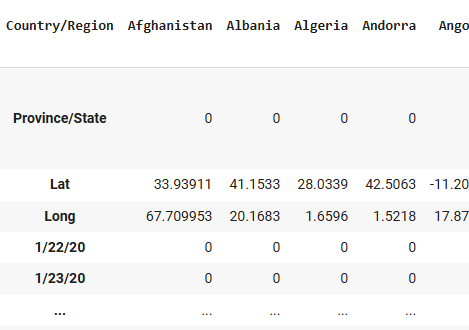

In [45]:
dft = df.T
dft

,0,1,2,3,4,5,6,7,8,9,...,279,280,281,282,283,284,285,286,287,288
Province/State,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Australian Capital Territory,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,Australia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
Lat,33.93911,41.1533,28.0339,42.5063,-11.2027,-71.9499,17.0608,-38.4161,40.0691,-35.4735,...,-32.5228,41.377491,-15.3767,6.4238,14.058324,31.9522,39.9042,15.552727,-13.133897,-19.015438
Long,67.709953,20.1683,1.6596,1.5218,17.8739,23.347,-61.7964,-63.6167,45.0382,149.0124,...,-55.7658,64.585262,166.9592,-66.5897,108.277199,35.2332,116.4074,48.516388,27.849332,29.154857
1/22/20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3/5/23,209390,334427,271477,47875,105277,11,9106,10044125,446819,232619,...,1034303,251071,12014,552051,11526966,703228,535,11945,343135,264127
3/6/23,209406,334427,271477,47875,105277,11,9106,10044957,446819,232619,...,1034303,251071,12014,552125,11526966,703228,535,11945,343135,264127
3/7/23,209436,334427,271490,47875,105277,11,9106,10044957,446819,232619,...,1034303,251071,12014,552157,11526986,703228,535,11945,343135,264127
3/8/23,209451,334443,271494,47890,105288,11,9106,10044957,447308,232619,...,1034303,251247,12014,552157,11526994,703228,535,11945,343135,264276


To keep on confirmed cases data, we would like to select only rows below `Lat` and `Long` rows from the DataFrame.

*   `DataFrame.iloc[]` uses index location to select data by location.



In [46]:
# Select only rows below Lat and Long rows from the DataFrame.
dftbl = dft.iloc[4:-1]
dftbl

,0,1,2,3,4,5,6,7,8,9,...,279,280,281,282,283,284,285,286,287,288
1/22/20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1/23/20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
1/24/20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
1/25/20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
1/26/20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3/4/23,209369,334427,271469,47875,105277,11,9106,10044125,446819,232619,...,1034303,251071,12014,552051,11526962,703228,535,11945,343079,264127
3/5/23,209390,334427,271477,47875,105277,11,9106,10044125,446819,232619,...,1034303,251071,12014,552051,11526966,703228,535,11945,343135,264127
3/6/23,209406,334427,271477,47875,105277,11,9106,10044957,446819,232619,...,1034303,251071,12014,552125,11526966,703228,535,11945,343135,264127
3/7/23,209436,334427,271490,47875,105277,11,9106,10044957,446819,232619,...,1034303,251071,12014,552157,11526986,703228,535,11945,343135,264127


**`DataFrame.reset_index(level=None, *, drop=False, inplace=False, col_level=0) `** Reset the index of the DataFrame, and use the default instead (0, 1, 2, ...). If the DataFrame has a MultiIndex, this method can remove one or more levels. (Only frequently used arguments are shown here)
*   `level`: (optional) levels to reset. Default resets all levels.
*   `drop`: (optional) do not try to insert index into dataframe columns. Default is `False`.
*   `inplace`: (optional) modify DataFrame rather than creating a new one. Default is `False`.
*   `col_level`: (optional) for multi level columns, specifies on which level to reset the indexes Default is `0`.
*   **Returns**: DataFrame with the new index. If `inplace=True`, return nothing.

In [47]:
ridf = dftbl.reset_index()
ridf

,index,0,1,2,3,4,5,6,7,8,...,279,280,281,282,283,284,285,286,287,288
0,1/22/20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1/23/20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2,1/24/20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
3,1/25/20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
4,1/26/20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1137,3/4/23,209369,334427,271469,47875,105277,11,9106,10044125,446819,...,1034303,251071,12014,552051,11526962,703228,535,11945,343079,264127
1138,3/5/23,209390,334427,271477,47875,105277,11,9106,10044125,446819,...,1034303,251071,12014,552051,11526966,703228,535,11945,343135,264127
1139,3/6/23,209406,334427,271477,47875,105277,11,9106,10044957,446819,...,1034303,251071,12014,552125,11526966,703228,535,11945,343135,264127
1140,3/7/23,209436,334427,271490,47875,105277,11,9106,10044957,446819,...,1034303,251071,12014,552157,11526986,703228,535,11945,343135,264127


As the column that contains date was originally `index`, after resetting the index, the name for this column has become "`index`". Rename this column to "`date`". (Only frequently used arguments are shown here)

**`DataFrame.rename(index=None, columns=None, inplace=False, level=None, errors='ignore')`** Rename the column labels.
*   `index` : (Optional) Dictionary where the old index is the key and the new index is the value.
*   `columns` : (Optional) Dictionary where the old label is the key and the new label is the value.
*   `inplace`: (optional) modify DataFrame rather than creating a new one. Default is `False`.
*   `col_level`: (optional) for multi level columns, specifies on which level to rename.




In [48]:
# Rename column 'index' to 'Date'. Modify the original DataFrame
rndf = ridf.rename(columns = {"index":"date"})
rndf

,date,0,1,2,3,4,5,6,7,8,...,279,280,281,282,283,284,285,286,287,288
0,1/22/20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1/23/20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2,1/24/20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
3,1/25/20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
4,1/26/20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1137,3/4/23,209369,334427,271469,47875,105277,11,9106,10044125,446819,...,1034303,251071,12014,552051,11526962,703228,535,11945,343079,264127
1138,3/5/23,209390,334427,271477,47875,105277,11,9106,10044125,446819,...,1034303,251071,12014,552051,11526966,703228,535,11945,343135,264127
1139,3/6/23,209406,334427,271477,47875,105277,11,9106,10044957,446819,...,1034303,251071,12014,552125,11526966,703228,535,11945,343135,264127
1140,3/7/23,209436,334427,271490,47875,105277,11,9106,10044957,446819,...,1034303,251071,12014,552157,11526986,703228,535,11945,343135,264127


Change the data type in `'Date'` column from `String` to `datetime`.

**`pandas.to_datetime(arg)`** converts argument to datetime.

*   `dayfirst`: `bool`, If `True`, parses dates with the day first (default is `False`)
*   `yearfirst` : `bool`, If `True`, parses dates with the year first (default `False`)

In [49]:
rndf["date"] = pd.to_datetime(rndf["date"])
rndf

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29752\2223148683.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rndf["date"] = pd.to_datetime(rndf["date"])


,date,0,1,2,3,4,5,6,7,8,...,279,280,281,282,283,284,285,286,287,288
0,2020-01-22,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2020-01-23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2,2020-01-24,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
3,2020-01-25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
4,2020-01-26,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1137,2023-03-04,209369,334427,271469,47875,105277,11,9106,10044125,446819,...,1034303,251071,12014,552051,11526962,703228,535,11945,343079,264127
1138,2023-03-05,209390,334427,271477,47875,105277,11,9106,10044125,446819,...,1034303,251071,12014,552051,11526966,703228,535,11945,343135,264127
1139,2023-03-06,209406,334427,271477,47875,105277,11,9106,10044957,446819,...,1034303,251071,12014,552125,11526966,703228,535,11945,343135,264127
1140,2023-03-07,209436,334427,271490,47875,105277,11,9106,10044957,446819,...,1034303,251071,12014,552157,11526986,703228,535,11945,343135,264127


Set the Date column to be the index of the DataFrame.

**`DataFrame.set_index(keys, *, drop=True, append=False, inplace=False, verify_integrity=False)`** set the DataFrame index (row labels) using one or more existing columns or arrays (of the correct length). The index can replace the existing index or expand on it. (Only frequently used arguments are shown here)
*   `keys` : either a single column key (label), a single array of the same length as the calling DataFrame, or a list containing an arbitrary combination of column keys and arrays
*   `drop` : If `True`, delete columns to be used as the new index. Default is `True`.
*   `append` : If `True`, append columns to existing index. Default is `False`.
*   `inplace` : If `True`, modify the DataFrame rather than creating a new one. Default is `False`.
*   `verify_integrity` : If `True`, check the new index for duplicates. Otherwise defer the check until necessary. Default is `False`.


In [50]:
rsidf = rndf.set_index(rndf["date"])
rsidf.drop("date", axis=1, inplace=True)
rsidf

,0,1,2,3,4,5,6,7,8,9,...,279,280,281,282,283,284,285,286,287,288
date,,,,,,,,,,,,,,,,,,,,,
2020-01-22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-01-23,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-26,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-04,209369,334427,271469,47875,105277,11,9106,10044125,446819,232619,...,1034303,251071,12014,552051,11526962,703228,535,11945,343079,264127
2023-03-05,209390,334427,271477,47875,105277,11,9106,10044125,446819,232619,...,1034303,251071,12014,552051,11526966,703228,535,11945,343135,264127
2023-03-06,209406,334427,271477,47875,105277,11,9106,10044957,446819,232619,...,1034303,251071,12014,552125,11526966,703228,535,11945,343135,264127


Observe the resulting DataFrame

**Visualize Data Using Pandas**

**`Series.plot(*args, **kwargs)`** or **`DataFrame.plot(*args, **kwargs)`** makes plots of Series or DataFrame (Only frequently used arguments are shown here)
*   `figsize` : tuple (`width`, `height`) in inches
*   `title` : Title to use for the plot.
*   `xlabel` : Name to use for the xlabel on x-axis. Default uses index name.
*   `ylabel` : Name to use for the ylabel on y-axis. Default shows no ylabel.
*   `x` : label or position. Only used if data is a DataFrame.
*   `y` : label, position or list of label, positions. Allows plotting of one column versus another. Only used if data is a DataFrame.
*   `y` : Name to use for the ylabel on y-axis. Default shows no ylabel.
*   `**kwargs` : Options to pass to matplotlib plotting method

C:\Users\ASUS\AppData\Local\Temp\ipykernel_29752\1520250080.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ndf = sdf.reset_index()


<Axes: >

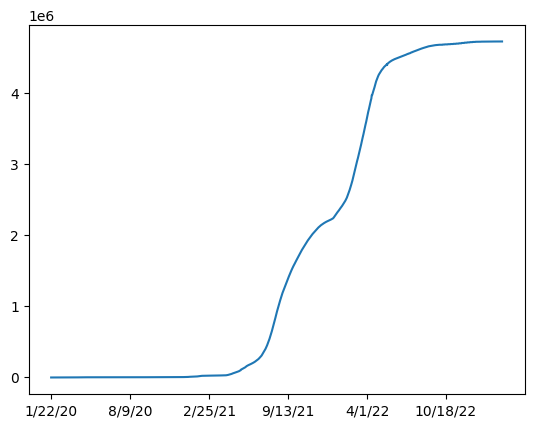

In [70]:
# Plot Thailand cases
ndf = sdf.reset_index()
tdf = ndf[ndf["Country/Region"] == "Thailand"]
tdf.drop("Country/Region", axis=1, inplace=True)
tdf = tdf.iloc[0]
tdf.name = "cases"
tdf.plot()

For the plot, Set xticks to monthly and rotate x label.

In [ ]:
# prompt: Set xticks to monthly and rotate x label


Disable scientific format for y-axis for latest plot.

In [ ]:
# prompt: Disable scientific format for y-axis for latest plot


In [ ]:
# Plot cases for Thailand, Vietnam, and Burma.


In [ ]:
# Plot cases for China, Japan, and Korea, South.


In [ ]:
# Plot cases for France, Italy, United Kingdom, and Germany.


In [ ]:
# Plot cases for US, India, Brazil, and Russia.


In [72]:
# Plot cases for Thailand, Iceland, Taiwan*, and Grenada.
sdf

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
Albania,0,0,0,0,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
Algeria,0,0,0,0,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
Andorra,0,0,0,0,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
Angola,0,0,0,0,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
West Bank and Gaza,0,0,0,0,0,0,0,0,0,0,...,703228,703228,703228,703228,703228,703228,703228,703228,703228,703228
Winter Olympics 2022,0,0,0,0,0,0,0,0,0,0,...,535,535,535,535,535,535,535,535,535,535
Yemen,0,0,0,0,0,0,0,0,0,0,...,11945,11945,11945,11945,11945,11945,11945,11945,11945,11945


# Covid19 Data Visualization using Seaborn
Seaborn is a Python data visualization library based on matplotlib. It uses Matplotlib underneath to plot graphs. See https://seaborn.pydata.org/.

<Axes: xlabel='Country/Region', ylabel='9/15/20'>

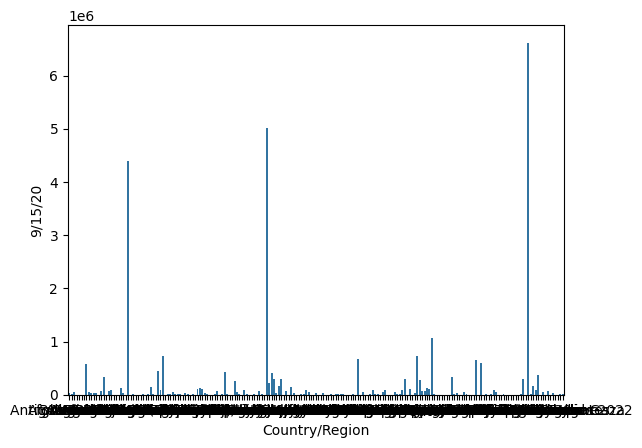

In [74]:
# Observe the original DataFrame fetched from the URL.
import seaborn as sns

sns.barplot(sdf["9/15/20"])

Using seaborn, plot bar graph of confirmed cases for every Country/Region on 9/15/20.

**`seaborn.barplot(data=None, x=None, y=None)`** A bar plot represents an aggregate or statistical estimate for a numeric variable with the height of each rectangle and indicates the uncertainty around that estimate using an error bar. Bar plots include 0 in the axis range, and they are a good choice when 0 is a meaningful value for the variable to take. (Only frequently used arguments are shown here)

*   `data` : Dataset for plotting
*   `x`, `y` : names of variables in `data` or vector data
*   `hue` : name of variable for setting color hue (Prior to v0.13.0, each bar would have a different color. To replicate this behavior, assign the grouping variable to `hue`)

**Return:** `ax` Axes object with the plot drawn onto it.



In [75]:
import matplotlib.pyplot as plt

plt.subplots(sdf["9/15/20"])

ValueError: Number of rows must be a positive integer, not Country/Region
Afghanistan             38901
Albania                 11672
Algeria                 48734
Andorra                  1438
Angola                   3569
                        ...  
West Bank and Gaza      32250
Winter Olympics 2022        0
Yemen                    2016
Zambia                  13819
Zimbabwe                 7576
Name: 9/15/20, Length: 201, dtype: int64

<Figure size 640x480 with 0 Axes>

Use `Matplotlib` with `pyplot` module.

**`matplotlib.pyplot.subplots(nrows=1, ncols=1, **fig_kw)`** create common layouts of subplots, including the enclosing figure object. (Only frequently used arguments are shown here)

*   `nrows`, `ncols` : Number of rows/columns of the subplot grid. Default is 1 row and 1 column.
*   `**fig_kw` : All additional keyword arguments are passed to the `pyplot.figure` call.

**Return :**
*   `fig` : figure
*   `ax` : A single Axes object, or an array of Axes objects if more than one subplot was created.

**Plot Settings**

`matplotlib`'s `Axes` class represents Axes object encapsulates all the elements of an individual (sub-)plot in a figure. Properties can be accessed using setter, getters.





**Sort & Select**

To plot only data from Country/Region with top 20 number of confirmed cases, (1) sort data in descending order and (2) slice data for top 20 rows.

**`DataFrame.sort_values(by, axis=0, ascending=True, inplace=False, kind='quicksort', na_position='last')`** sorts a DataFrame by one or more columns in ascending or descending order. (Only frequently used arguments are shown here)
*   `by` : labels to sort by
*   `axis` : axis to sort by (0=sorting rows, 1=sorting columns). Default is 0.
*   `ascending` : sort in ascending order. Default is `True`.
*   `inplace` : modifies the original DataFrame. Default is `False`.
*   `kind`: sorting algorithm: 'quicksort', 'mergesort', or 'heapsort'.
*   `na_position`: 'first' or 'last'; defines position of `NaN` values. Default is 'last'.





In [ ]:
# Plot the data from Country/Region with top 20 number of confirmed cases on 9/15/20


**Find correlation between data using pandas**

**`DataFrame.corr()`** calculates the relationship between each column in your data set.


In [77]:
# Store data in time_series_df
sdf.corr()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
1/22/20,1.000000,0.999988,0.999981,0.999981,0.999984,0.999981,0.999982,0.999980,0.999978,0.999980,...,0.013389,0.013375,0.013364,0.013353,0.013351,0.013349,0.013347,0.013339,0.013329,0.013319
1/23/20,0.999988,1.000000,0.999993,0.999988,0.999987,0.999984,0.999983,0.999981,0.999978,0.999980,...,0.013205,0.013192,0.013181,0.013170,0.013168,0.013166,0.013163,0.013155,0.013145,0.013135
1/24/20,0.999981,0.999993,1.000000,0.999992,0.999990,0.999987,0.999983,0.999981,0.999978,0.999980,...,0.014124,0.014110,0.014100,0.014088,0.014086,0.014084,0.014081,0.014074,0.014064,0.014054
1/25/20,0.999981,0.999988,0.999992,1.000000,0.999996,0.999994,0.999992,0.999992,0.999989,0.999990,...,0.013199,0.013185,0.013174,0.013163,0.013161,0.013159,0.013156,0.013149,0.013138,0.013128
1/26/20,0.999984,0.999987,0.999990,0.999996,1.000000,0.999998,0.999995,0.999995,0.999993,0.999994,...,0.013884,0.013871,0.013860,0.013849,0.013847,0.013845,0.013842,0.013835,0.013824,0.013815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3/5/23,0.013349,0.013166,0.014084,0.013159,0.013845,0.013165,0.012362,0.012374,0.012140,0.012399,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3/6/23,0.013347,0.013163,0.014081,0.013156,0.013842,0.013162,0.012359,0.012371,0.012137,0.012396,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3/7/23,0.013339,0.013155,0.014074,0.013149,0.013835,0.013155,0.012352,0.012363,0.012130,0.012389,...,0.999999,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3/8/23,0.013329,0.013145,0.014064,0.013138,0.013824,0.013145,0.012342,0.012353,0.012120,0.012379,...,0.999999,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [78]:
# Calculate correlation between countries (similarity)
tdf.corr()

TypeError: Series.corr() missing 1 required positional argument: 'other'

**Visualization with Heatmap**

Use heatmap to visualize the correlation. It shows 2D correlation matrix between two discrete dimensions, using colored cells to represent data. The values of the first dimension appear as the rows of the table while of the second dimension as a column. The color of the cell is proportional to the number of measurements that match the dimensional value.

**`seaborn.heatmap(data, vmin=None, vmax=None, cmap=None, cbar=True)`** Plot rectangular data as a color-encoded matrix. (Only frequently used arguments are shown here)
*   `data` : 2D dataset. If DataFrame is provided, index/column information will be used to label the columns and rows.
*   `vmin`, `vmax` : Values to anchor the colormap, otherwise they are inferred from the data and other keyword arguments.
*   `cmap` : matplotlib colormap name or object, or list of colors. See: https://matplotlib.org/stable/users/explain/colors/colormaps.html#colormaps
*   `cbar` : Whether to draw a colorbar. Default is `True`.



In [ ]:
# Plot heatmap of correlation DataFrame sorted by column 'Thailand' in descending order.


# Using Scatter Plot by Seaborn and Plotly

Use scatter plot to plot the relationship between two numerical variables (x- and y- variables.) In this case, scatter plot can be used to visualize relationship between number of confirm cases and death cases.



Read confirmed cases from the previously used `time_series_covid19_confirmed_global.csv`.

In [ ]:
confirmed_df=pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv')


Read confirmed cases from `time_series_covid19_deaths_global.csv`.

In [ ]:
death_df=pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv')


**Merge DataFrame**

We can merge DataFrames for the rows with common values in specified columns (database-style join).This will concatenate the columns from the DataFrame being merged in.

**`DataFrame.merge(right, how='inner', on=None, left_on=None, right_on=None, sort=False, suffixes=('_x', '_y'))`** Merge DataFrame or named Series objects with a database-style join. (Only frequently used arguments are shown here)

*   `right` : DataFrame to merge with
*   `on` : Column or index level names to join on.
*   `how` : Type of merge to be performed (`'left'`, `'right'`, `'outer'`, `'inner'` (Default), `'cross'`).
; preserve

  *   `left` = use only keys from left frame, similar to a SQL left outer join; preserve key order.
  *   `right` = use only keys from right frame, similar to a SQL right outer join; preserve key order.
  *   `outer` = use union of keys from both frames, similar to a SQL full outer join; sort keys lexicographically.
  *   `inner` = use intersection of keys from both frames, similar to a SQL inner join; preserve the order of the left keys.
  *   `cross` = creates the cartesian product from both frames, preserves the order of the left keys.
*   `left_on` : Column or index level names to join on in the left DataFrame.
*   `right_on` : Column or index level names to join on in the right DataFrame.
*   `suffixes` : A length-2 sequence where each element is optionally a string indicating the suffix to add to overlapping column names in left and right respectively. Default is ("`_x`", "`_y`")

Currently, `Country/Region` is the index. To move `Country/Region` to be a column, reset the index to the default numeric value (0, 1, 2, 3, etc.)

**Use Scatter Plot**

**`seaborn.scatterplot(data=None, *, x=None, y=None, hue=None, size=None, style=None, legend='auto')`** Draw a scatter plot with possibility of several semantic groupings. (Only frequently used arguments are shown here)

*   `data` : Input data structure such as DataFrame
*   `x`, `y` : Variables that specify positions on the x and y axes.
*   `hue` : Grouping variable that will produce points with different colors.
*   `size` : Grouping variable that will produce points with different sizes.
*   `style` : Grouping variable that will produce points with different markers.
*   `legend` : How to draw the legend. ("auto", "brief", "full", or `False`)




In [ ]:
# Scatter Plot with '9/15/20_Confirmed' as x-axis and '9/15/20_Death' as y-axis


**Plotly**

Plotly is interactive graphing library for Python. The plotly.express module (usually imported as `px`) contains functions recommended as starting point for creating most common figures. See https://plotly.com/python/plotly-express/

**`px.scatter(df, x, y, color)`** : Giving DataFrame and x and y given as DataFrame columns, each data point is represented as a marker point, whose location is given by the x and y columns. (Only frequently used arguments are shown here)
*   `df` : DataFrame
*   `x` : Column for x axis
*   `y` : Column for y axis
*   `color` : Column for different colors


